TASK 1

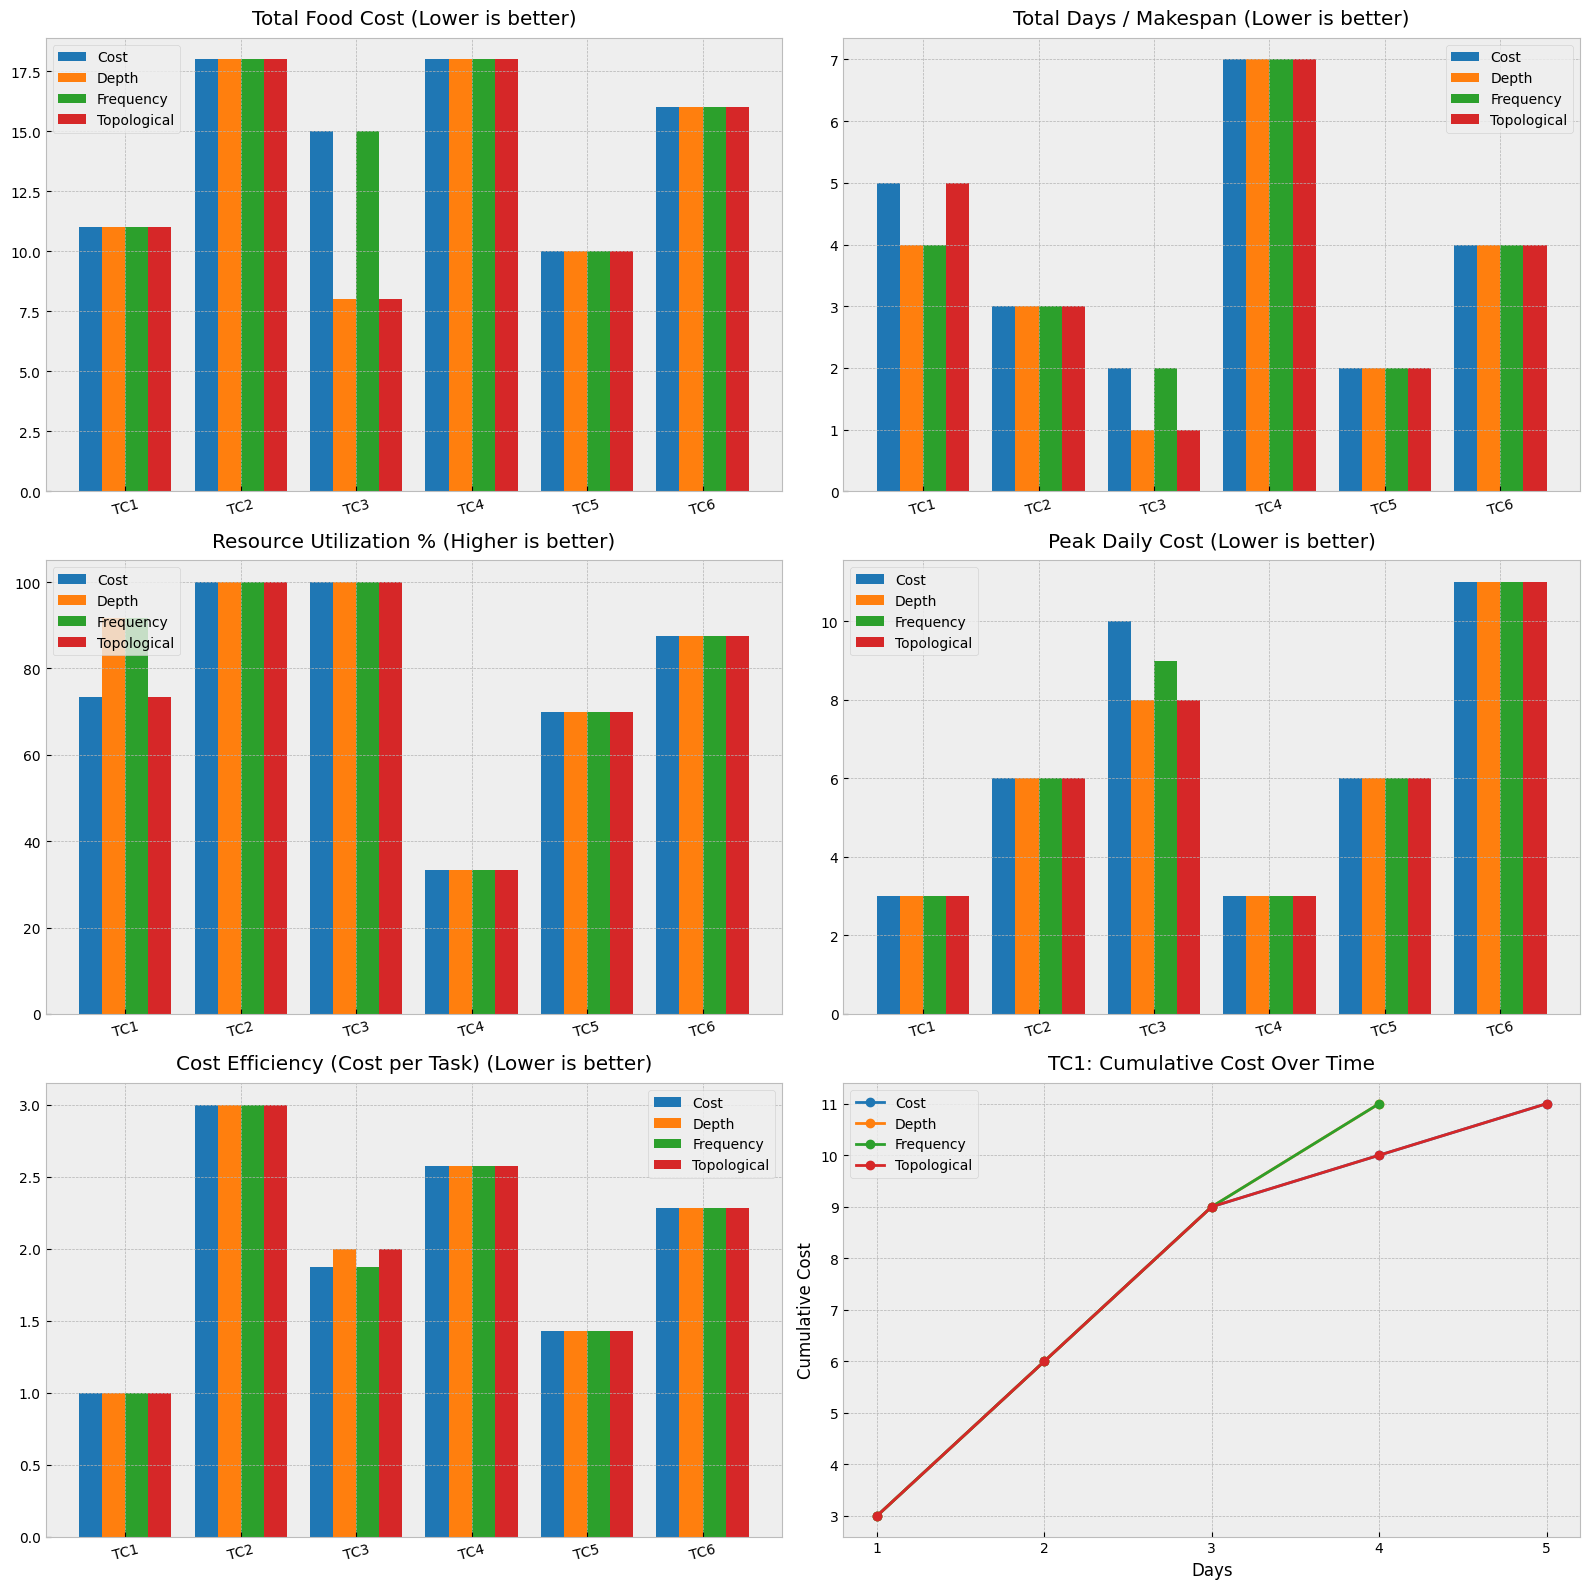

In [7]:
import copy
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import numpy as np

class AssignmentScheduler:
    def __init__(self, input_string):
        self.food_costs = {}
        self.group_size = 0
        self.inputs = []
        self.outputs = []
        self.assignments = {}
        self.graph = defaultdict(list)
        self.in_degree = defaultdict(int)
        self.target_assignments = set()
        self.parse_input(input_string)
        self.build_graph()

    def parse_input(self, data):
        lines = data.strip().split('\n')
        for line in lines:
            parts = line.split()
            if not parts or parts[0] == 'Comments': continue

            if parts[0] == 'C': self.food_costs[parts[1]] = int(parts[2])
            elif parts[0] == 'G': self.group_size = int(parts[1])
            elif parts[0] == 'I': self.inputs = [p for p in parts[1:] if p != '-1']
            elif parts[0] == 'O': self.outputs = [p for p in parts[1:] if p != '-1']
            elif parts[0] == 'A':
                a_id = 'A' + parts[1]
                in1, in2, out, food = parts[2], parts[3], parts[4], parts[5]
                deps = [i for i in (in1, in2) if i != '-1']
                self.assignments[a_id] = {'deps': deps, 'food': food, 'out': out}

    def build_graph(self):
        out_to_node = {out: 'Input' for out in self.inputs}
        for a_id, data in self.assignments.items():
            out_to_node[data['out']] = a_id
            self.in_degree[a_id] = 0

        for a_id, data in self.assignments.items():
            for dep in data['deps']:
                if dep in out_to_node and out_to_node[dep] != 'Input':
                    parent = out_to_node[dep]
                    self.graph[parent].append(a_id)
                    self.in_degree[a_id] += 1

            if data['out'] in self.outputs:
                self.target_assignments.add(a_id)

    def calculate_depths(self):
        depths = {}
        def get_depth(node):
            if node in depths: return depths[node]
            if not self.graph[node]:
                return 1
            depths[node] = max(get_depth(child) for child in self.graph[node]) + 1
            return depths[node]
        for a_id in self.assignments:
            if a_id not in depths: get_depth(a_id)
        return depths

    def run_greedy(self, strategy_name):
        in_degree = copy.deepcopy(self.in_degree)
        available = [node for node in self.assignments if in_degree[node] == 0]
        completed = set()

        schedule_log = []
        daily_costs = []
        total_cost = 0
        depths = self.calculate_depths() if strategy_name == 'depth' else {}

        while not self.target_assignments.issubset(completed):
            if not available: break

            if strategy_name == 'cost':
                available.sort(key=lambda x: self.food_costs[self.assignments[x]['food']])
            elif strategy_name == 'depth':
                available.sort(key=lambda x: depths.get(x, 0), reverse=True)
            elif strategy_name == 'frequency':
                remaining = set(self.assignments.keys()) - completed
                freq = Counter(self.assignments[r]['food'] for r in remaining)
                available.sort(key=lambda x: freq[self.assignments[x]['food']], reverse=True)
            elif strategy_name == 'topological':
                available.sort(key=lambda x: int(x[1:]))

            today_tasks = available[:self.group_size]

            today_foods = [self.assignments[task]['food'] for task in today_tasks]
            food_counts = Counter(today_foods)
            menu_cost = sum(count * self.food_costs[food] for food, count in food_counts.items())

            total_cost += menu_cost
            daily_costs.append(menu_cost)
            schedule_log.append(today_tasks)

            available = available[self.group_size:]
            for task in today_tasks:
                completed.add(task)
                for child in self.graph[task]:
                    in_degree[child] -= 1
                    if in_degree[child] == 0:
                        available.append(child)

        return {
            'days': len(schedule_log),
            'total_cost': total_cost,
            'tasks_done': len(completed),
            'utilization': (len(completed) / (len(schedule_log) * self.group_size)) * 100 if schedule_log else 0,
            'peak_cost': max(daily_costs) if daily_costs else 0,
            'daily_costs': daily_costs
        }

# --- 6 Diverse Test Cases ---
test_cases = {
    "TC1: Original Problem": """
C TC 1\nC DF 1\nC PM 1\nC GJ 1\nG 3\nI 1 2 3 4 5 6 -1\nO 13 14 17 -1
A 1 1 3 7 TC\nA 2 4 2 8 TC\nA 3 1 3 9 TC\nA 4 2 3 10 PM\nA 5 7 8 11 TC
A 6 4 6 12 TC\nA 7 6 9 13 PM\nA 8 10 5 14 GJ\nA 9 1 11 15 DF
A 10 3 12 16 TC\nA 11 15 16 17 DF
""",
    "TC2: The Distractor Trap": """
C TC 5\nC DF 1\nG 2\nI 1 -1\nO 10 -1
A 1 1 -1 2 TC\nA 2 2 -1 3 TC\nA 3 3 -1 10 TC
A 4 1 -1 5 DF\nA 5 5 -1 6 DF\nA 6 6 -1 7 DF\nA 7 7 -1 8 DF
""",
    "TC3: Wide/Parallel Graph": """
C TC 2\nC DF 1\nC PM 3\nG 4\nI 1 -1\nO 11 12 13 14 -1
A 1 1 -1 11 TC\nA 2 1 -1 12 PM\nA 3 1 -1 13 DF\nA 4 1 -1 14 TC
A 5 1 -1 15 PM\nA 6 1 -1 16 DF\nA 7 1 -1 17 TC\nA 8 1 -1 18 DF
""",
    "TC4: The Bottleneck Chain": """
C TC 3\nC DF 2\nG 3\nI 1 -1\nO 8 -1
A 1 1 -1 2 TC\nA 2 2 -1 3 DF\nA 3 3 -1 4 TC\nA 4 4 -1 5 DF
A 5 5 -1 6 TC\nA 6 6 -1 7 DF\nA 7 7 -1 8 TC
""",
    "TC5: High Capacity (G=5)": """
C TC 1\nC PM 2\nG 5\nI 1 2 3 -1\nO 10 11 -1
A 1 1 -1 4 TC\nA 2 2 -1 5 TC\nA 3 3 -1 6 PM\nA 4 4 -1 7 TC
A 5 5 -1 8 PM\nA 6 4 5 10 PM\nA 7 6 -1 11 TC
""",
    "TC6: Expensive Bridge": """
C TC 10\nC DF 1\nG 2\nI 1 -1\nO 10 11 -1
A 1 1 -1 2 DF\nA 2 2 -1 3 TC\nA 3 3 -1 10 DF
A 4 1 -1 5 DF\nA 5 5 -1 6 DF\nA 6 6 -1 7 DF\nA 7 7 -1 11 DF
"""
}

# --- Execution & Data Gathering ---
strategies = ['cost', 'depth', 'frequency', 'topological']
metrics = {'cost': [], 'days': [], 'utilization': [], 'peak_cost': [], 'efficiency': []}
tc_names = list(test_cases.keys())
tc1_trajectories = {}

for tc_name, tc_data in test_cases.items():
    scheduler = AssignmentScheduler(tc_data)
    tc_results = {m: [] for m in metrics.keys()}

    for strategy in strategies:
        res = scheduler.run_greedy(strategy)
        tc_results['cost'].append(res['total_cost'])
        tc_results['days'].append(res['days'])
        tc_results['utilization'].append(res['utilization'])
        tc_results['peak_cost'].append(res['peak_cost'])

        # New Metric: Cost per task completed (Lower is better)
        efficiency = res['total_cost'] / res['tasks_done'] if res['tasks_done'] > 0 else 0
        tc_results['efficiency'].append(efficiency)

        if tc_name == "TC1: Original Problem":
            # Calculate cumulative cost for the line chart
            cum_cost = np.cumsum(res['daily_costs']).tolist()
            tc1_trajectories[strategy] = cum_cost

    for m in metrics.keys():
        metrics[m].append(tc_results[m])

for m in metrics.keys():
    metrics[m] = list(map(list, zip(*metrics[m])))

# --- Advanced Plotting ---
plt.style.use('bmh') # Cleaner style
fig, axs = plt.subplots(3, 2, figsize=(16, 16))
x = np.arange(len(tc_names))
width = 0.2

# Bar Charts
plot_configs = [
    (axs[0, 0], 'Total Food Cost (Lower is better)', metrics['cost']),
    (axs[0, 1], 'Total Days / Makespan (Lower is better)', metrics['days']),
    (axs[1, 0], 'Resource Utilization % (Higher is better)', metrics['utilization']),
    (axs[1, 1], 'Peak Daily Cost (Lower is better)', metrics['peak_cost']),
    (axs[2, 0], 'Cost Efficiency (Cost per Task) (Lower is better)', metrics['efficiency'])
]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for ax, title, data in plot_configs:
    for i, strategy in enumerate(strategies):
        ax.bar(x + (i - 1.5) * width, data[i], width, label=strategy.capitalize(), color=colors[i])
    ax.set_title(title, pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels([f"TC{i+1}" for i in range(len(tc_names))], rotation=15)
    ax.legend()

# Line Chart: Cumulative Cost Trajectory for TC1
ax_line = axs[2, 1]
for i, strategy in enumerate(strategies):
    trajectory = tc1_trajectories[strategy]
    days = range(1, len(trajectory) + 1)
    ax_line.plot(days, trajectory, marker='o', linewidth=2, label=strategy.capitalize(), color=colors[i])

ax_line.set_title("TC1: Cumulative Cost Over Time", pad=10)
ax_line.set_xlabel("Days")
ax_line.set_ylabel("Cumulative Cost")
ax_line.set_xticks(range(1, max(len(t) for t in tc1_trajectories.values()) + 1))
ax_line.legend()

plt.tight_layout()
plt.show()

TASK 2


In [8]:
import heapq
from collections import defaultdict, Counter, deque
from itertools import combinations

class OptimalScheduler:
    def __init__(self, input_string):
        self.food_costs = {}
        self.group_size = 0
        self.inputs, self.outputs = [], []
        self.assignments = {}
        self.out_to_node = {}
        self.parse_input(input_string)
        self.necessary_tasks = self.get_necessary_tasks()
        self.graph = self.build_graph()

    def parse_input(self, data):
        lines = data.strip().split('\n')
        for line in lines:
            parts = line.split()
            if not parts or parts[0] == 'Comments': continue

            if parts[0] == 'C': self.food_costs[parts[1]] = int(parts[2])
            elif parts[0] == 'G': self.group_size = int(parts[1])
            elif parts[0] == 'I': self.inputs = [p for p in parts[1:] if p != '-1']
            elif parts[0] == 'O': self.outputs = [p for p in parts[1:] if p != '-1']
            elif parts[0] == 'A':
                a_id = 'A' + parts[1]
                deps = [i for i in (parts[2], parts[3]) if i != '-1']
                self.assignments[a_id] = {'deps': deps, 'food': parts[5], 'out': parts[4]}
                self.out_to_node[parts[4]] = a_id

        for inp in self.inputs:
            self.out_to_node[inp] = 'Input'

    def build_graph(self):
        graph = defaultdict(list)
        for a_id, data in self.assignments.items():
            for dep in data['deps']:
                if dep in self.out_to_node and self.out_to_node[dep] != 'Input':
                    graph[self.out_to_node[dep]].append(a_id)
        return graph

    def get_necessary_tasks(self):
        """Reverse BFS to isolate tasks strictly needed for the final outputs."""
        necessary = set()
        queue = deque([self.out_to_node[out] for out in self.outputs if out in self.out_to_node and self.out_to_node[out] != 'Input'])

        while queue:
            curr = queue.popleft()
            if curr not in necessary:
                necessary.add(curr)
                for dep in self.assignments[curr]['deps']:
                    parent = self.out_to_node.get(dep)
                    if parent and parent != 'Input':
                        queue.append(parent)
        return necessary

    def heuristic(self, completed_tasks):
        """h(n): Sum of costs for remaining necessary tasks."""
        remaining = self.necessary_tasks - completed_tasks
        return sum(self.food_costs[self.assignments[t]['food']] for t in remaining)

    def run_astar(self):
        start_state = frozenset()

        # Priority Queue: (f_cost, days (tie-breaker for speed), insert_order, g_cost, state, schedule, menus)
        pq = []
        tie_breaker = 0
        heapq.heappush(pq, (self.heuristic(start_state), 0, tie_breaker, 0, start_state, [], []))

        visited_g = {start_state: 0}
        states_explored = 0

        while pq:
            f, days, _, g, completed, schedule, menus = heapq.heappop(pq)
            states_explored += 1

            # Goal Check
            if self.necessary_tasks.issubset(completed):
                return {'schedule': schedule, 'menus': menus, 'days': days, 'cost': g, 'states': states_explored}

            # Pruning
            if g > visited_g.get(completed, float('inf')):
                continue

            # Find Available Necessary Tasks
            available = []
            for task in self.necessary_tasks:
                if task not in completed:
                    deps_met = all(
                        self.out_to_node.get(dep) == 'Input' or self.out_to_node.get(dep) in completed
                        for dep in self.assignments[task]['deps']
                    )
                    if deps_met: available.append(task)

            # Generate all valid moves for the day (up to group capacity)
            valid_moves = []
            for r in range(1, min(self.group_size, len(available)) + 1):
                valid_moves.extend(list(combinations(available, r)))

            for move in valid_moves:
                new_completed = completed.union(move)

                # Calculate daily menu cost
                food_counts = Counter([self.assignments[t]['food'] for t in move])
                move_cost = sum(count * self.food_costs[food] for food, count in food_counts.items())

                new_g = g + move_cost

                if new_g < visited_g.get(new_completed, float('inf')):
                    visited_g[new_completed] = new_g
                    new_f = new_g + self.heuristic(new_completed)

                    menu_str = ", ".join([f"{count}-{food}" for food, count in food_counts.items()])
                    new_menus = menus + [{'tasks': move, 'menu': menu_str, 'cost': move_cost}]

                    tie_breaker += 1
                    heapq.heappush(pq, (new_f, days + 1, tie_breaker, new_g, new_completed, schedule + [move], new_menus))

        return None

    def run_greedy_depth(self):
        """Minimal greedy depth implementation for comparison metrics."""
        in_degree = {a: 0 for a in self.assignments}
        for parent, children in self.graph.items():
            for child in children: in_degree[child] += 1

        depths = {}
        def get_depth(node):
            if node in depths: return depths[node]
            if node not in self.graph or not self.graph[node]: return 1
            depths[node] = max(get_depth(child) for child in self.graph[node]) + 1
            return depths[node]
        for a_id in self.assignments: get_depth(a_id)

        available = [node for node in self.assignments if in_degree[node] == 0]
        completed = set()
        days = 0
        total_cost = 0
        target_assignments = {self.out_to_node[out] for out in self.outputs if out in self.out_to_node and self.out_to_node[out] != 'Input'}

        while not target_assignments.issubset(completed) and available:
            available.sort(key=lambda x: depths.get(x, 0), reverse=True)
            today_tasks = available[:self.group_size]
            food_counts = Counter([self.assignments[t]['food'] for t in today_tasks])
            total_cost += sum(c * self.food_costs[f] for f, c in food_counts.items())

            days += 1
            available = available[self.group_size:]
            for task in today_tasks:
                completed.add(task)
                for child in self.graph.get(task, []):
                    in_degree[child] -= 1
                    if in_degree[child] == 0: available.append(child)

        return {'cost': total_cost, 'days': days}

# --- Execute on Test Cases ---
test_cases = {
    "TC1: Original Problem": "\nC TC 1\nC DF 1\nC PM 1\nC GJ 1\nG 3\nI 1 2 3 4 5 6 -1\nO 13 14 17 -1\nA 1 1 3 7 TC\nA 2 4 2 8 TC\nA 3 1 3 9 TC\nA 4 2 3 10 PM\nA 5 7 8 11 TC\nA 6 4 6 12 TC\nA 7 6 9 13 PM\nA 8 10 5 14 GJ\nA 9 1 11 15 DF\nA 10 3 12 16 TC\nA 11 15 16 17 DF",
    "TC2: The Distractor Trap": "\nC TC 5\nC DF 1\nG 2\nI 1 -1\nO 10 -1\nA 1 1 -1 2 TC\nA 2 2 -1 3 TC\nA 3 3 -1 10 TC\nA 4 1 -1 5 DF\nA 5 5 -1 6 DF\nA 6 6 -1 7 DF\nA 7 7 -1 8 DF",
    "TC3: Wide Graph": "\nC TC 2\nC DF 1\nC PM 3\nG 4\nI 1 -1\nO 11 12 13 14 -1\nA 1 1 -1 11 TC\nA 2 1 -1 12 PM\nA 3 1 -1 13 DF\nA 4 1 -1 14 TC\nA 5 1 -1 15 PM\nA 6 1 -1 16 DF\nA 7 1 -1 17 TC\nA 8 1 -1 18 DF",
    "TC4: The Bottleneck Chain": "\nC TC 3\nC DF 2\nG 3\nI 1 -1\nO 8 -1\nA 1 1 -1 2 TC\nA 2 2 -1 3 DF\nA 3 3 -1 4 TC\nA 4 4 -1 5 DF\nA 5 5 -1 6 TC\nA 6 6 -1 7 DF\nA 7 7 -1 8 TC",
    "TC5: High Capacity": "\nC TC 1\nC PM 2\nG 5\nI 1 2 3 -1\nO 10 11 -1\nA 1 1 -1 4 TC\nA 2 2 -1 5 TC\nA 3 3 -1 6 PM\nA 4 4 -1 7 TC\nA 5 5 -1 8 PM\nA 6 4 5 10 PM\nA 7 6 -1 11 TC",
    "TC6: Expensive Bridge": "\nC TC 10\nC DF 1\nG 2\nI 1 -1\nO 10 11 -1\nA 1 1 -1 2 DF\nA 2 2 -1 3 TC\nA 3 3 -1 10 DF\nA 4 1 -1 5 DF\nA 5 5 -1 6 DF\nA 6 6 -1 7 DF\nA 7 7 -1 11 DF"
}

for name, data in test_cases.items():
    print(f"=======================================\n{name}\n=======================================")
    scheduler = OptimalScheduler(data)

    # Run A*
    astar_res = scheduler.run_astar()

    # Run Greedy (Depth) for comparison
    greedy_res = scheduler.run_greedy_depth()

    print("--- Optimal A* Schedule ---")
    for i, day in enumerate(astar_res['menus']):
        print(f"Day-{i+1}: {', '.join(day['tasks'])}")
        print(f"   Menu: {day['menu']} -> Cost: {day['cost']}")

    print(f"\nTotal Days Taken: {astar_res['days']}")
    print(f"Total Food Cost:  {astar_res['cost']}")
    print(f"States Explored:  {astar_res['states']}\n")

    cost_diff = greedy_res['cost'] - astar_res['cost']
    day_diff = greedy_res['days'] - astar_res['days']

    print("--- Comparison vs Best Greedy (Depth) ---")
    print(f"Greedy Cost: {greedy_res['cost']} | A* Cost: {astar_res['cost']} -> Savings: {cost_diff}")
    print(f"Greedy Days: {greedy_res['days']}  | A* Days: {astar_res['days']}  -> Difference: {day_diff}\n")

TC1: Original Problem
--- Optimal A* Schedule ---
Day-1: A2, A1
   Menu: 2-TC -> Cost: 2
Day-2: A5, A4, A6
   Menu: 2-TC, 1-PM -> Cost: 3
Day-3: A10, A3, A9
   Menu: 2-TC, 1-DF -> Cost: 3
Day-4: A8, A11, A7
   Menu: 1-GJ, 1-DF, 1-PM -> Cost: 3

Total Days Taken: 4
Total Food Cost:  11
States Explored:  171

--- Comparison vs Best Greedy (Depth) ---
Greedy Cost: 11 | A* Cost: 11 -> Savings: 0
Greedy Days: 4  | A* Days: 4  -> Difference: 0

TC2: The Distractor Trap
--- Optimal A* Schedule ---
Day-1: A1
   Menu: 1-TC -> Cost: 5
Day-2: A2
   Menu: 1-TC -> Cost: 5
Day-3: A3
   Menu: 1-TC -> Cost: 5

Total Days Taken: 3
Total Food Cost:  15
States Explored:  4

--- Comparison vs Best Greedy (Depth) ---
Greedy Cost: 18 | A* Cost: 15 -> Savings: 3
Greedy Days: 3  | A* Days: 3  -> Difference: 0

TC3: Wide Graph
--- Optimal A* Schedule ---
Day-1: A3, A4, A1, A2
   Menu: 1-DF, 2-TC, 1-PM -> Cost: 8

Total Days Taken: 1
Total Food Cost:  8
States Explored:  16

--- Comparison vs Best Greedy (Depth

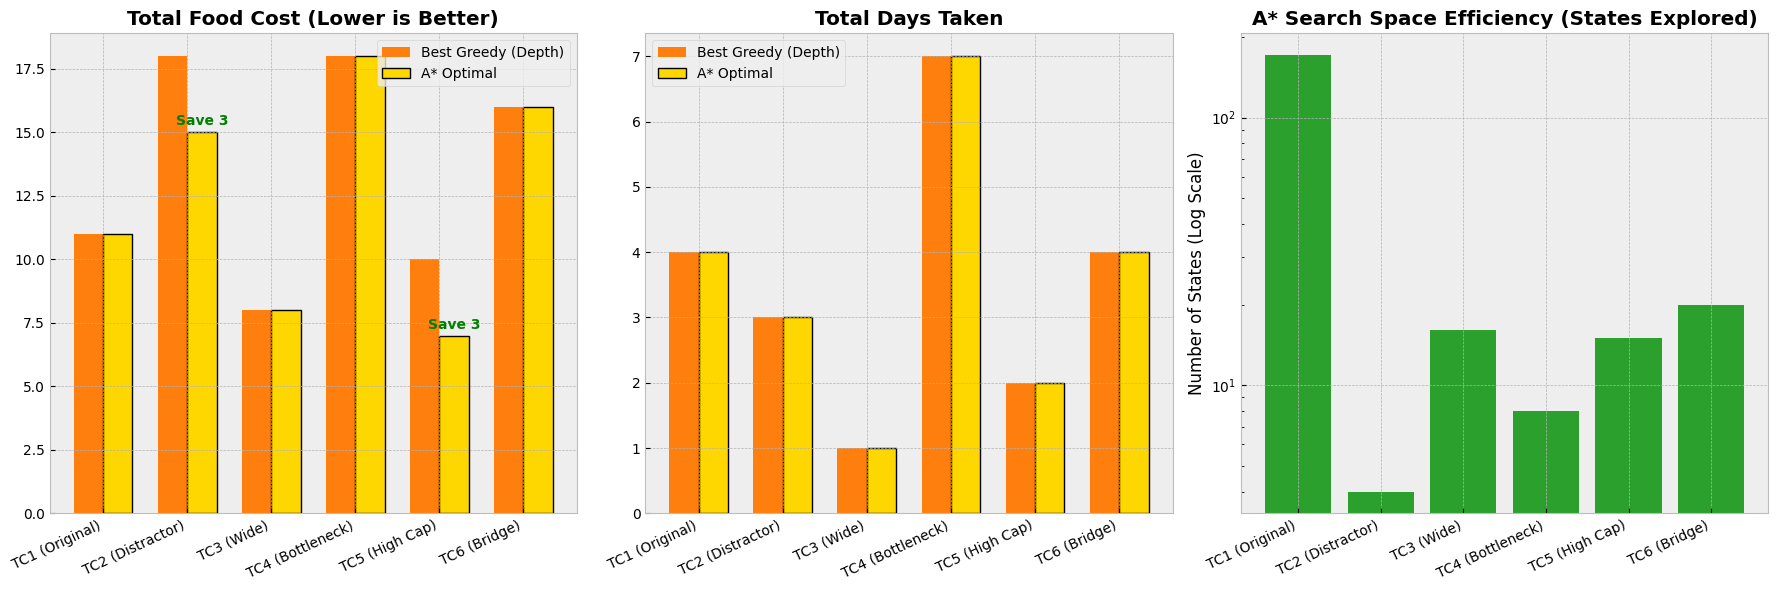

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Data extracted from A* vs Greedy console output
test_cases = ['TC1 (Original)', 'TC2 (Distractor)', 'TC3 (Wide)', 'TC4 (Bottleneck)', 'TC5 (High Cap)', 'TC6 (Bridge)']

# Total Cost Data
greedy_cost = [11, 18, 8, 18, 10, 16]
astar_cost = [11, 15, 8, 18, 7, 16]

# Total Days Data
greedy_days = [4, 3, 1, 7, 2, 4]
astar_days = [4, 3, 1, 7, 2, 4]

# States Explored (Efficiency Metric for A*)
astar_states = [171, 4, 16, 8, 15, 20]

x = np.arange(len(test_cases))
width = 0.35

plt.style.use('bmh')
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Cost Comparison
axs[0].bar(x - width/2, greedy_cost, width, label='Best Greedy (Depth)', color='#ff7f0e')
axs[0].bar(x + width/2, astar_cost, width, label='A* Optimal', color='#ffd700', edgecolor='black', linewidth=1)
axs[0].set_title('Total Food Cost (Lower is Better)', fontweight='bold')
axs[0].set_xticks(x)
axs[0].set_xticklabels(test_cases, rotation=25, ha='right')
axs[0].legend()

# Annotate savings
for i in range(len(test_cases)):
    if greedy_cost[i] > astar_cost[i]:
        axs[0].annotate(f'Save {greedy_cost[i] - astar_cost[i]}',
                        xy=(x[i] + width/2, astar_cost[i]),
                        xytext=(0, 5), textcoords='offset points', ha='center', color='green', fontweight='bold')

# Plot 2: Days Comparison
axs[1].bar(x - width/2, greedy_days, width, label='Best Greedy (Depth)', color='#ff7f0e')
axs[1].bar(x + width/2, astar_days, width, label='A* Optimal', color='#ffd700', edgecolor='black', linewidth=1)
axs[1].set_title('Total Days Taken', fontweight='bold')
axs[1].set_xticks(x)
axs[1].set_xticklabels(test_cases, rotation=25, ha='right')
axs[1].legend()

# Plot 3: States Explored
axs[2].bar(x, astar_states, color='#2ca02c')
axs[2].set_title('A* Search Space Efficiency (States Explored)', fontweight='bold')
axs[2].set_xticks(x)
axs[2].set_xticklabels(test_cases, rotation=25, ha='right')
axs[2].set_yscale('log') # Log scale because TC1 is much higher than the rest
axs[2].set_ylabel('Number of States (Log Scale)')

plt.tight_layout()
plt.show()